In [1]:
import pandas as pd 
import numpy as np

In [2]:
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("train (1).csv", usecols=['Age' , 'Fare' , 'Survived'])

In [4]:
df.dropna(inplace=True)

In [5]:
df.shape

(714, 3)

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [14]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2 , random_state=42)

In [15]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [16]:
clf = DecisionTreeClassifier()

In [17]:
clf.fit(X_train,Y_train)
y_pred = clf.predict(X_test)

In [18]:
accuracy_score(Y_test,y_pred)

0.6223776223776224

In [19]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6330985915492957)

In [21]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [22]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [23]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

/var/data/python/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/var/data/python/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [28]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [29]:
output = pd.DataFrame({
    'age' : X_train['Age'],
    'age_trf' : X_train_trf[:,0],
    'fare' : X_train['Fare'],
    'fare_trf' : X_train_trf[:,1]
})

In [30]:
output['age_labels'] = pd.cut(x=X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [31]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
293,24.0,3.0,8.8500,2.0,"(22.0, 25.0]","(7.896, 9.225]"
777,5.0,0.0,12.4750,3.0,"(0.42, 14.0]","(9.225, 13.0]"
561,40.0,7.0,7.8958,2.0,"(36.0, 42.0]","(7.75, 7.896]"
759,33.0,6.0,86.5000,9.0,"(32.0, 36.0]","(82.171, 512.329]"
731,11.0,0.0,18.7875,5.0,"(0.42, 14.0]","(15.75, 26.0]"


In [32]:
clf = DecisionTreeClassifier()
clf.fit(X_train,Y_train)
y_pred2 = clf.predict(X_test_trf)

/var/data/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [33]:
accuracy_score(Y_test,y_pred2)

0.3916083916083916

In [34]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

/var/data/python/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/var/data/python/lib/python3.13/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6317097026604068)

In [46]:
def discretize(bins, strategy):

    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    trf = ColumnTransformer([
        ('age', kbin_age, ['Age']),
        ('fare', kbin_fare, ['Fare'])
    ])

    X_trf = trf.fit_transform(X)

    print(
        np.mean(
            cross_val_score(
                DecisionTreeClassifier(),
                X_trf,
                y,
                cv=10,
                scoring='accuracy'
            )
        )
    )

    # Age Comparison
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Age'], bins=20)
    plt.title("Age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0], bins=bins)
    plt.title("Age After")

    plt.show()

    # Fare Comparison
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Fare'], bins=20)
    plt.title("Fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1], bins=bins, color='red')
    plt.title("Fare After")

    

    plt.show()

0.6864632237871675


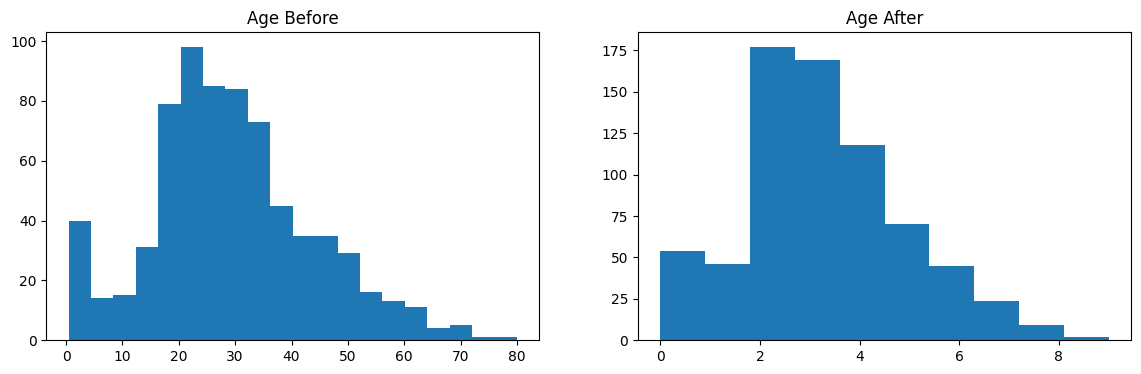

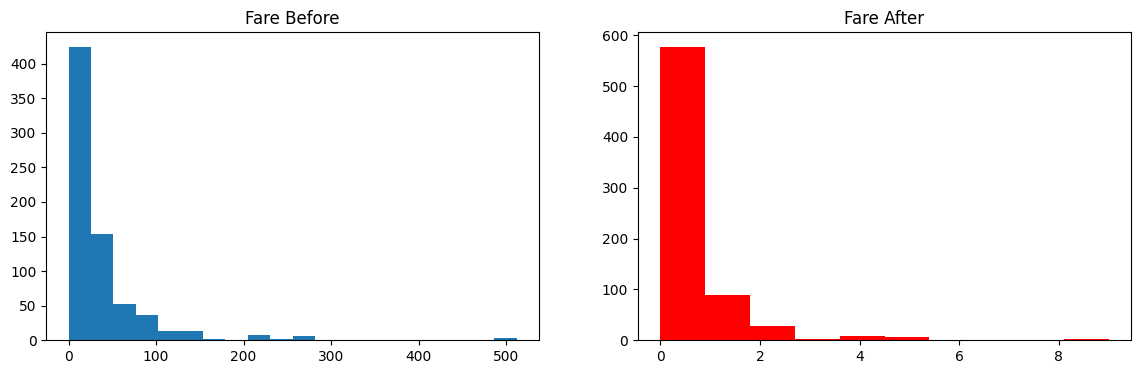

In [47]:
discretize(10,'uniform')